Shape: (10000, 14)
   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86              1          0               1   
2       8  159660.80              3          1               0   
3       1       0.00              2          0               0   
4       2  125510.82              1          1               1   

   EstimatedSalary  Exited  
0        101348.88       1  
1        112542.58       0  
2        113931.57       1  
3         93826.63     

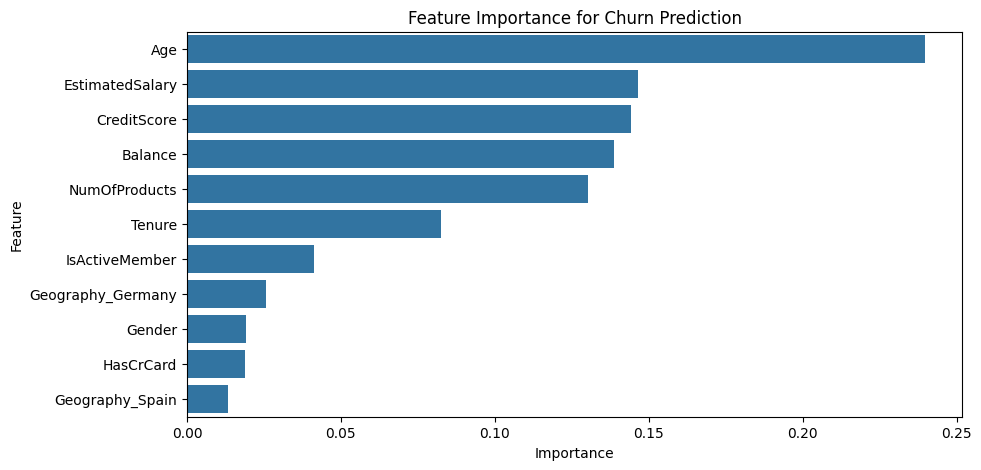

In [1]:
# ==========================================
# Name: Faiza Memon
# TASK 3: CUSTOMER CHURN PREDICTION
# DevelopersHub Internship
# ==========================================

# ---------------- IMPORT LIBRARIES ----------------
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# ---------------- LOAD DATASET ----------------
df = pd.read_csv("Churn_Modelling.csv")

# ---------------- BASIC INFO ----------------
print("Shape:", df.shape)
print(df.head())
print(df.info())

# ---------------- DROP IRRELEVANT COLUMNS ----------------
df = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

# ---------------- CHECK MISSING VALUES ----------------
print(df.isnull().sum())

# ---------------- ENCODING CATEGORICAL FEATURES ----------------
le = LabelEncoder()

df['Gender'] = le.fit_transform(df['Gender'])   # Male/Female → 0/1

# Geography → One Hot Encoding
df = pd.get_dummies(df, columns=['Geography'], drop_first=True)

# ---------------- SPLIT DATA ----------------
X = df.drop('Exited', axis=1)
y = df['Exited']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ---------------- MODEL TRAINING ----------------
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# ---------------- PREDICTION ----------------
y_pred = model.predict(X_test)

# ---------------- EVALUATION ----------------
accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("\nAccuracy:", accuracy)
print("\nConfusion Matrix:\n", cm)
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# ---------------- FEATURE IMPORTANCE ----------------
importance = model.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

print("\nFeature Importance:\n", feature_importance)

# ---------------- PLOT FEATURE IMPORTANCE ----------------
plt.figure(figsize=(10,5))
sns.barplot(x='Importance', y='Feature', data=feature_importance)
plt.title("Feature Importance for Churn Prediction")
plt.show()